Ensemble: Random Forest + Gradient Boosting + Logistic/Ridge Regression

Predicts:
- Heat stroke probability
- Dehydration risk score (0–100)
- Heat stress level (0–3)

In [1]:
!pip install scikit-learn pandas numpy joblib matplotlib seaborn -q
print('✓ Done')

✓ Done


In [2]:
from google.colab import files
import io, pandas as pd

print('Upload your CSV...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
raw_df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded: {filename}  |  Shape: {raw_df.shape}')
raw_df.head(3)

Upload your CSV...


Saving heatstroke_data.csv to heatstroke_data.csv
Loaded: heatstroke_data.csv  |  Shape: (609, 27)


,Daily Ingested Water (L),Time of year (month),Cardiovascular disease history,Dehydration,Heat Index (HI),Diastolic BP,Environmental temperature (C),Sickle Cell Trait (SCT),Systolic BP,Weight (kg),...,Heart / Pulse rate (b/min),Age,Sweating,"Skin color (flushed/normal=1, pale=0.5, cyatonic=0)",Strenuous exercise,Nationality,Sex,Hot/dry skin,Time of day,Heat stroke
0,2.821588,7.000000,0,0,107.296910,20.0,39.0,0,60.0,48.364079,...,166.0,38.0,0,0.021014,0.5,1,1,0,10.550628,1
1,5.000000,6.841842,0,0,105.410610,90.0,37.7,0,120.0,52.413863,...,68.0,50.0,1,0.045987,0.0,1,0,0,10.613669,1
2,5.000000,4.636197,0,0,101.823065,50.0,37.7,0,100.0,46.344503,...,96.0,64.0,0,0.031299,0.0,1,0,0,14.419615,1


In [3]:
import numpy as np
import pandas as pd
import joblib, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score)
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':'#0D0D0D','axes.facecolor':'#1A1A1A',
    'axes.edgecolor':'#444','axes.labelcolor':'#CCC',
    'xtick.color':'#888','ytick.color':'#888',
    'text.color':'#CCC','grid.color':'#333','grid.linestyle':'--',
    'font.family':'monospace',
})
FLAME='#FF4B00'; GOLD='#FFB800'; GREEN='#00C48C'; BLUE='#4A9EFF'

FEATURES = [
    'water_L','month','cvd','HI','diastolic','env_temp','SCT',
    'systolic','weight','humidity','sun_exposure','BMI','exertional',
    'baro','HR','age','sweating','skin_color','exercise','sex',
    'hot_dry_skin','hour','dehydration',
]

COL_MAP = {
    'Daily Ingested Water (L)':                              'water_L',
    'Time of year (month)':                                  'month',
    'Cardiovascular disease history':                        'cvd',
    'Dehydration':                                           'dehydration',
    'Heat Index (HI)':                                       'HI',
    'Diastolic BP':                                          'diastolic',
    'Environmental temperature (C)':                        'env_temp',
    'Sickle Cell Trait (SCT)':                              'SCT',
    'Systolic BP':                                           'systolic',
    'Weight (kg)':                                           'weight',
    'Patient temperature':                                   'pt_temp',
    'Rectal temperature (deg C)':                           'rectal_temp',
    'Relative Humidity':                                     'humidity',
    'Exposure to sun':                                       'sun_exposure',
    'BMI':                                                   'BMI',
    'Exertional (1) vs classic (0)':                        'exertional',
    'Barometric Pressure':                                   'baro',
    'Heart / Pulse rate (b/min)':                           'HR',
    'Age':                                                   'age',
    'Sweating':                                              'sweating',
    'Skin color (flushed/normal=1, pale=0.5, cyatonic=0)': 'skin_color',
    'Strenuous exercise':                                    'exercise',
    'Sex':                                                   'sex',
    'Hot/dry skin':                                          'hot_dry_skin',
    'Time of day':                                           'hour',
    'Heat stroke':                                           'heat_stroke',
}
print('Setup complete')

Setup complete


In [4]:
def gen_synthetic(n=2000):
    rows = []
    COLS = FEATURES + ['heat_stroke']
    for _ in range(n):
        profile  = np.random.choice(['low','moderate','high','extreme'], p=[0.35,0.30,0.25,0.10])
        month    = np.random.randint(1, 13)
        summer   = 1 if month in [4,5,6,7,8,9] else 0
        hour     = np.random.uniform(6, 20)
        midday   = 1 if 10 <= hour <= 16 else 0
        age      = np.random.randint(8, 85)
        weight   = np.random.uniform(35, 130)
        height   = np.random.uniform(1.45, 1.95)
        BMI      = weight / height**2
        cvd      = int(np.random.random() < (0.25 if age >= 65 else 0.05))
        SCT      = int(np.random.random() < 0.08)
        sex      = np.random.randint(0, 2)
        base_t   = {'low':25,'moderate':32,'high':38,'extreme':42}[profile]
        env_temp = np.clip(np.random.normal(base_t, 3), 15, 50)
        humidity = np.clip(np.random.beta(2,3)*(0.9-0.2*summer)+0.1, 0.05, 0.95)
        baro     = np.random.normal(29.97, 0.2)
        sun      = int(midday and summer and np.random.random() < 0.7)
        T_f = env_temp*9/5+32; RH = humidity*100
        HI  = max(-42.379+2.049*T_f+10.143*RH-0.225*T_f*RH
                  -0.00684*T_f**2-0.0548*RH**2+0.00122*T_f**2*RH
                  +0.000853*T_f*RH**2-0.00000199*T_f**2*RH**2, T_f)
        exertional  = int(np.random.random() < 0.4)
        exercise    = int(np.random.random() < (0.6 if exertional else 0.2))
        water_L     = np.clip(np.random.normal(3.0 if profile=='low' else 1.8, 0.8), 0.2, 8)
        dehydration = int(water_L < 1.5 or (water_L < 2.0 and profile in ['high','extreme']))
        HR          = np.clip(np.random.normal(80+20*(HI>100)+15*exertional+10*dehydration,12),50,200)
        systolic    = np.clip(np.random.normal(120+15*cvd+5*(age>=65)-10*(profile=='low'),12),60,200)
        diastolic   = np.clip(np.random.normal(80+10*cvd+3*(age>=65),8),40,130)
        pt_temp     = np.clip(np.random.normal(37+0.8*(HI>105)+0.5*exertional+0.3*dehydration,0.4),36,43)
        sweating    = int(pt_temp>37.5 and dehydration==0)
        hot_dry     = int(pt_temp>39.5 and dehydration==1)
        skin_color  = 1.0 if sweating else (0.5 if hot_dry else 0.0)
        hs_score    = (0.25*(pt_temp>40)+0.20*(HI>105)+0.15*exertional+0.10*dehydration
                      +0.08*cvd+0.07*(age>65 or age<12)+0.05*hot_dry+0.05*SCT+0.05*(water_L<1))
        heat_stroke = int((hs_score+np.random.normal(0,0.06))>0.45)
        rows.append([water_L,month,cvd,HI,diastolic,env_temp,SCT,systolic,weight,
                     humidity,sun,BMI,exertional,baro,HR,age,sweating,skin_color,
                     exercise,sex,hot_dry,hour,dehydration,heat_stroke])
    return pd.DataFrame(rows, columns=COLS)

# Clean real data
df_real = raw_df.rename(columns=COL_MAP)
for c in FEATURES:
    if c not in df_real.columns:
        df_real[c] = 0
df_real = df_real[FEATURES + ['heat_stroke']].dropna()

# Augment
df_syn = gen_synthetic(2000)
df = pd.concat([df_real, df_syn], ignore_index=True)

# Derived targets
df['dehydration_score'] = np.clip(
    (2.5-df['water_L'])*20 + (df['env_temp']-28).clip(0)*1.5
    + (df['humidity']*100-50).clip(0)*0.4 + df['dehydration']*25
    + df['hot_dry_skin']*15 + (1-df['sweating'])*5, 0, 100).round(1)

def heat_stress(row):
    s = 3 if row['HI']>130 else 2 if row['HI']>115 else 1 if row['HI']>103 else 0
    if row.get('cvd',0) or row.get('SCT',0): s = min(3,s+1)
    if row['age']>65 or row['age']<12: s = min(3,s+1)
    return s
df['heat_stress_level'] = df.apply(heat_stress, axis=1)

print(f'Real rows:      {len(df_real)}')
print(f'Synthetic rows: {len(df_syn)}')
print(f'Total:          {len(df)}')
print(f'Heat stroke prevalence: {df["heat_stroke"].mean():.2%}')
print(df['heat_stress_level'].value_counts().sort_index())

Real rows:      609
Synthetic rows: 2000
Total:          2609
Heat stroke prevalence: 8.55%
heat_stress_level
0    1374
1     685
2     319
3     231
Name: count, dtype: int64


## EDA

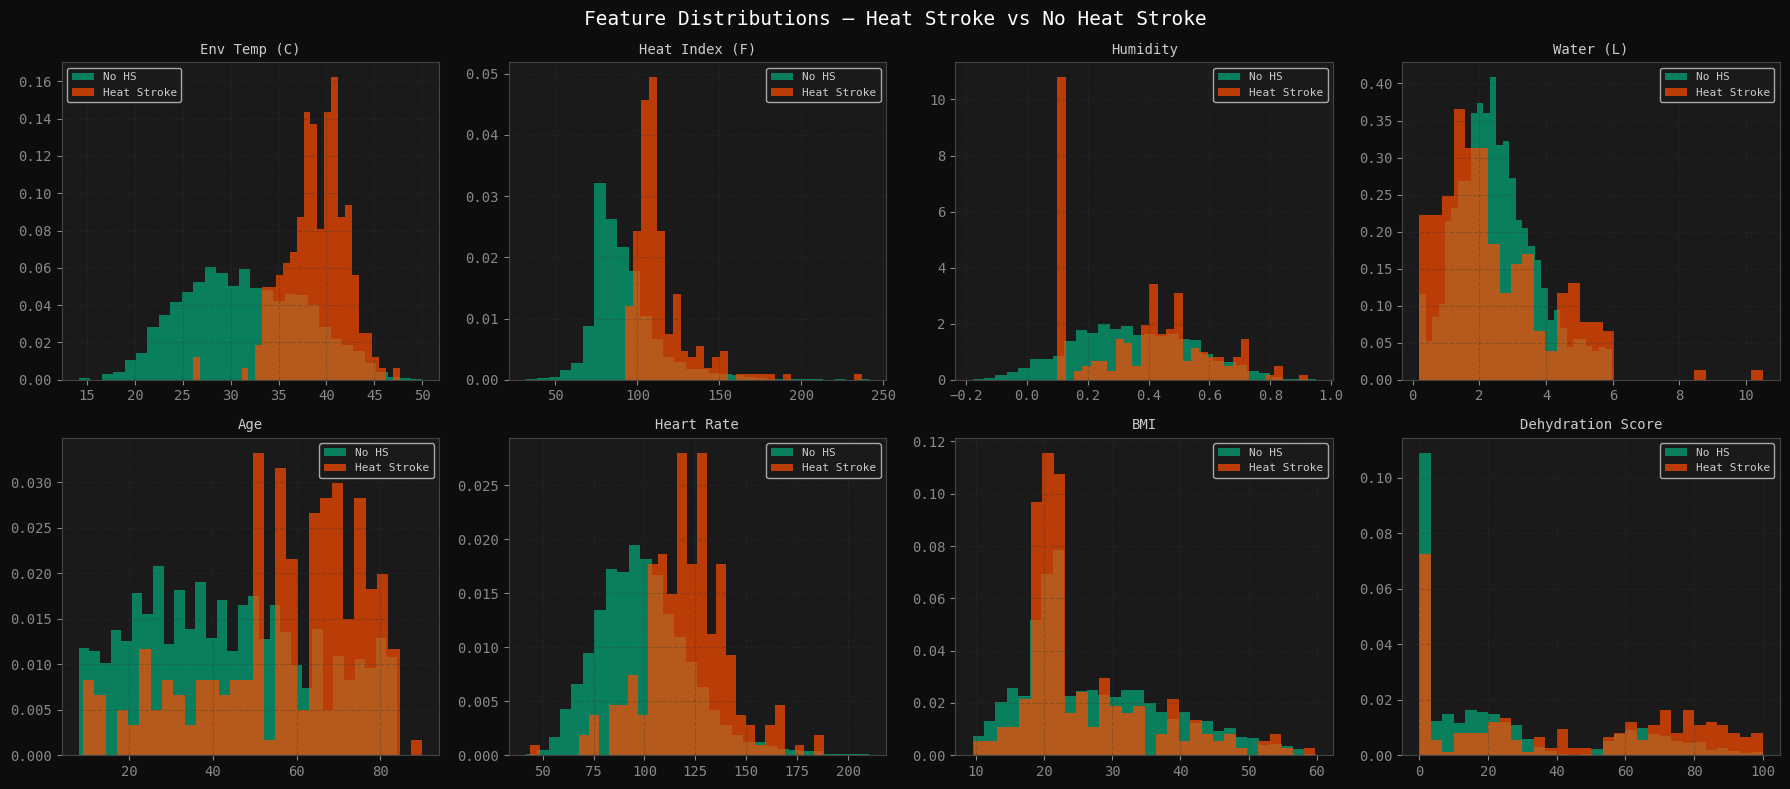

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions — Heat Stroke vs No Heat Stroke', fontsize=14, color='white')
plot_cols = ['env_temp','HI','humidity','water_L','age','HR','BMI','dehydration_score']
labels    = ['Env Temp (C)','Heat Index (F)','Humidity','Water (L)','Age','Heart Rate','BMI','Dehydration Score']
for ax, col, lbl in zip(axes.flat, plot_cols, labels):
    hs0 = df[df['heat_stroke']==0][col].dropna()
    hs1 = df[df['heat_stroke']==1][col].dropna()
    ax.hist(hs0, bins=30, alpha=0.6, color=GREEN, label='No HS', density=True)
    ax.hist(hs1, bins=30, alpha=0.7, color=FLAME, label='Heat Stroke', density=True)
    ax.set_title(lbl, fontsize=10); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

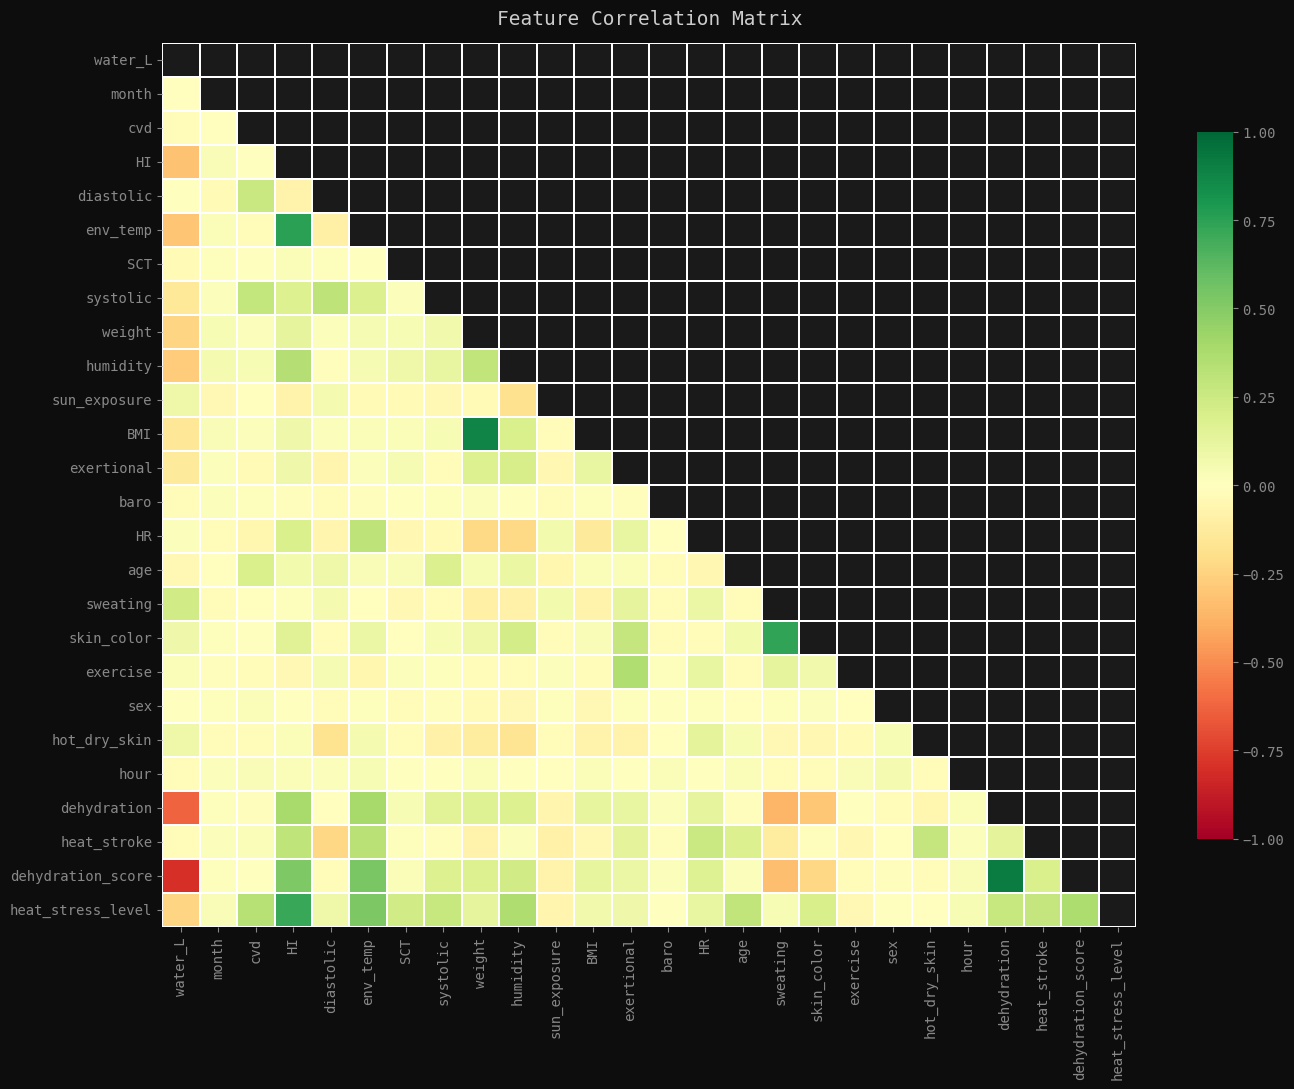

In [6]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[FEATURES + ['heat_stroke','dehydration_score','heat_stress_level']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=14)
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

## Model Training

In [7]:
scaler = StandardScaler()
X      = scaler.fit_transform(df[FEATURES].values)
y_hs   = df['heat_stroke'].values
y_dh   = df['dehydration_score'].values
y_hsl  = df['heat_stress_level'].values

X_tr,X_te,yhs_tr,yhs_te = train_test_split(X, y_hs, test_size=0.2, random_state=42, stratify=y_hs)
_,_,ydh_tr,ydh_te        = train_test_split(X, y_dh, test_size=0.2, random_state=42)
_,_,yhl_tr,yhl_te        = train_test_split(X, y_hsl, test_size=0.2, random_state=42)

print('Training... (~1 min)')

hs_rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
hs_gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
hs_lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
hs_rf.fit(X_tr, yhs_tr); hs_gb.fit(X_tr, yhs_tr); hs_lr.fit(X_tr, yhs_tr)

hs_aucs = [roc_auc_score(yhs_te, m.predict_proba(X_te)[:,1]) for m in [hs_rf,hs_gb,hs_lr]]
hs_w    = [a/sum(hs_aucs) for a in hs_aucs]
hs_ens  = sum(w*m.predict_proba(X_te)[:,1] for w,m in zip(hs_w,[hs_rf,hs_gb,hs_lr]))

dh_rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
dh_gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
dh_lr = Ridge(alpha=1.0)
dh_rf.fit(X_tr, ydh_tr); dh_gb.fit(X_tr, ydh_tr); dh_lr.fit(X_tr, ydh_tr)
dh_maes = [mean_absolute_error(ydh_te, m.predict(X_te)) for m in [dh_rf,dh_gb,dh_lr]]
dh_w    = [v/sum(1/m for m in dh_maes) for v in [1/m for m in dh_maes]]
dh_ens  = sum(w*m.predict(X_te) for w,m in zip(dh_w,[dh_rf,dh_gb,dh_lr]))

hsl_rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
hsl_gb = GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42)
hsl_rf.fit(X_tr, yhl_tr); hsl_gb.fit(X_tr, yhl_tr)
hsl_ens = np.clip(np.round(0.55*hsl_rf.predict(X_te)+0.45*hsl_gb.predict(X_te)).astype(int), 0, 3)

hs_thresh = (hs_ens >= 0.5).astype(int)
print('All models trained')

Training... (~1 min)
All models trained


## Performance Metrics

In [8]:
print('='*55)
print('HEAT STROKE')
print('='*55)
for n,a in zip(['RF','GB','LR'], hs_aucs):
    print(f'  {n} AUC: {a:.4f}')
print(f'  Ensemble AUC: {roc_auc_score(yhs_te, hs_ens):.4f}')
print(f'  Ensemble F1:  {f1_score(yhs_te, hs_thresh):.4f}')
print(f'  Ensemble Acc: {accuracy_score(yhs_te, hs_thresh):.4f}')
print()
print(classification_report(yhs_te, hs_thresh, target_names=['No HS','Heat Stroke']))

print('='*55)
print('DEHYDRATION SCORE')
print('='*55)
for n,m in zip(['RF','GB','LR'], dh_maes):
    print(f'  {n} MAE: {m:.3f}')
print(f'  Ensemble MAE:  {mean_absolute_error(ydh_te, dh_ens):.3f}')
print(f'  Ensemble RMSE: {mean_squared_error(ydh_te, dh_ens)**0.5:.3f}')
print(f'  Ensemble R2:   {r2_score(ydh_te, dh_ens):.4f}')

print()
print('='*55)
print('HEAT STRESS LEVEL')
print('='*55)
print(f'  Ensemble Accuracy:    {accuracy_score(yhl_te, hsl_ens):.4f}')
print(f'  Ensemble F1 (macro):  {f1_score(yhl_te, hsl_ens, average="macro"):.4f}')
print()
print(classification_report(yhl_te, hsl_ens, target_names=['Low','Moderate','High','Severe']))

HEAT STROKE
  RF AUC: 0.9870
  GB AUC: 0.9795
  LR AUC: 0.9692
  Ensemble AUC: 0.9873
  Ensemble F1:  0.7632
  Ensemble Acc: 0.9655

              precision    recall  f1-score   support

       No HS       0.97      1.00      0.98       477
 Heat Stroke       0.94      0.64      0.76        45

    accuracy                           0.97       522
   macro avg       0.95      0.82      0.87       522
weighted avg       0.96      0.97      0.96       522

DEHYDRATION SCORE
  RF MAE: 24.078
  GB MAE: 24.500
  LR MAE: 24.287
  Ensemble MAE:  24.149
  Ensemble RMSE: 28.719
  Ensemble R2:   -0.0070

HEAT STRESS LEVEL
  Ensemble Accuracy:    0.4904
  Ensemble F1 (macro):  0.1718

              precision    recall  f1-score   support

         Low       0.50      0.98      0.66       260
    Moderate       0.17      0.02      0.03       133
        High       0.00      0.00      0.00        82
      Severe       0.00      0.00      0.00        47

    accuracy                           0.49 

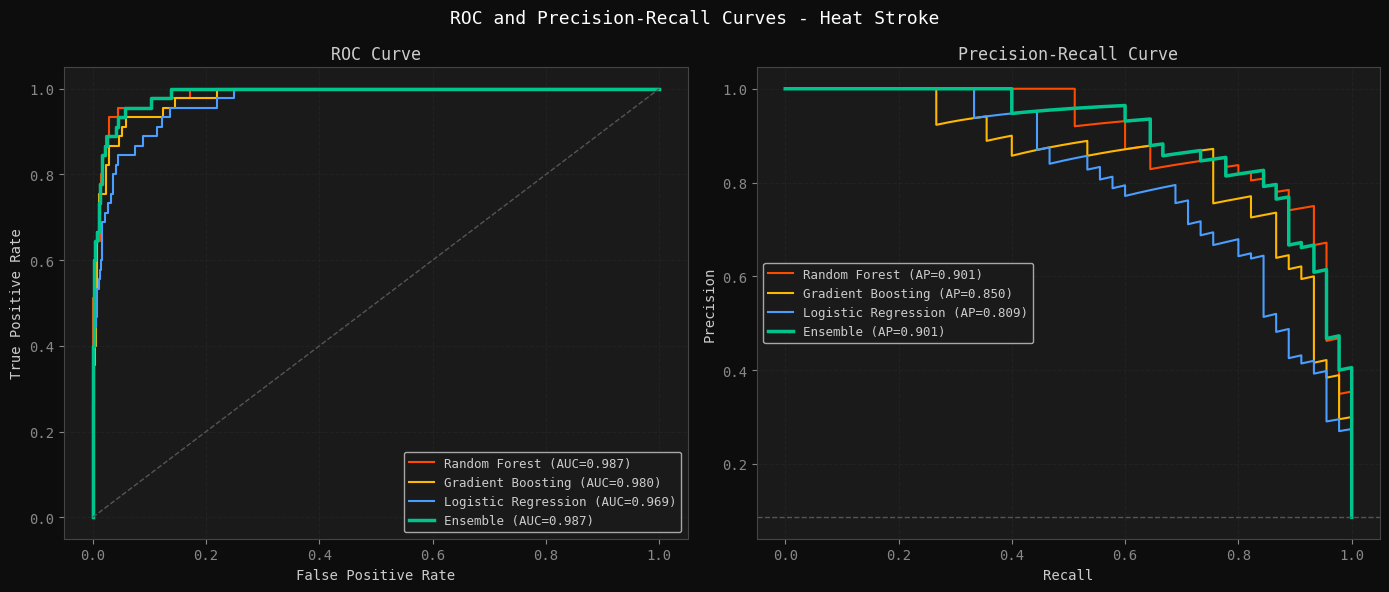

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC and Precision-Recall Curves - Heat Stroke', fontsize=13, color='white')

ax = axes[0]
for probs, name, color in [
    (hs_rf.predict_proba(X_te)[:,1],'Random Forest',FLAME),
    (hs_gb.predict_proba(X_te)[:,1],'Gradient Boosting',GOLD),
    (hs_lr.predict_proba(X_te)[:,1],'Logistic Regression',BLUE),
    (hs_ens,'Ensemble',GREEN),
]:
    fpr,tpr,_ = roc_curve(yhs_te, probs)
    lw = 2.5 if name=='Ensemble' else 1.5
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=color, lw=lw)
ax.plot([0,1],[0,1],'--',color='#555',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for probs, name, color in [
    (hs_rf.predict_proba(X_te)[:,1],'Random Forest',FLAME),
    (hs_gb.predict_proba(X_te)[:,1],'Gradient Boosting',GOLD),
    (hs_lr.predict_proba(X_te)[:,1],'Logistic Regression',BLUE),
    (hs_ens,'Ensemble',GREEN),
]:
    prec,rec,_ = precision_recall_curve(yhs_te, probs)
    ap = average_precision_score(yhs_te, probs)
    lw = 2.5 if name=='Ensemble' else 1.5
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=lw)
ax.axhline(yhs_te.mean(), color='#555', ls='--', lw=1)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

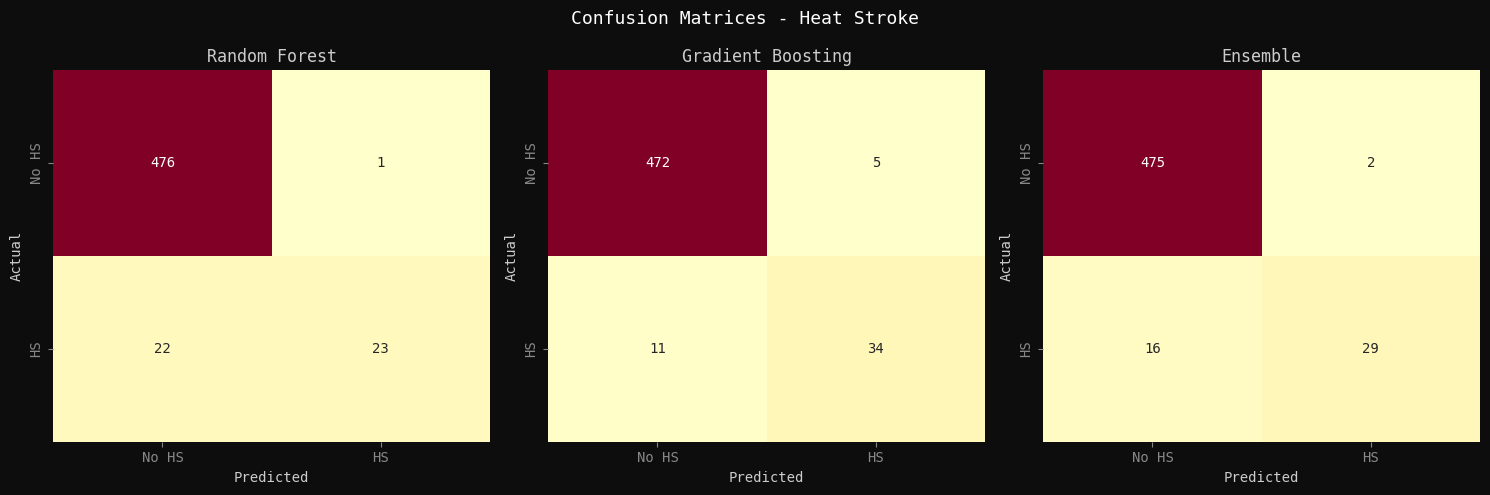

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices - Heat Stroke', fontsize=13, color='white')
for ax, pred, name in zip(axes,
    [hs_rf.predict(X_te), hs_gb.predict(X_te), hs_thresh],
    ['Random Forest','Gradient Boosting','Ensemble']):
    cm = confusion_matrix(yhs_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=['No HS','HS'], yticklabels=['No HS','HS'], cbar=False)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

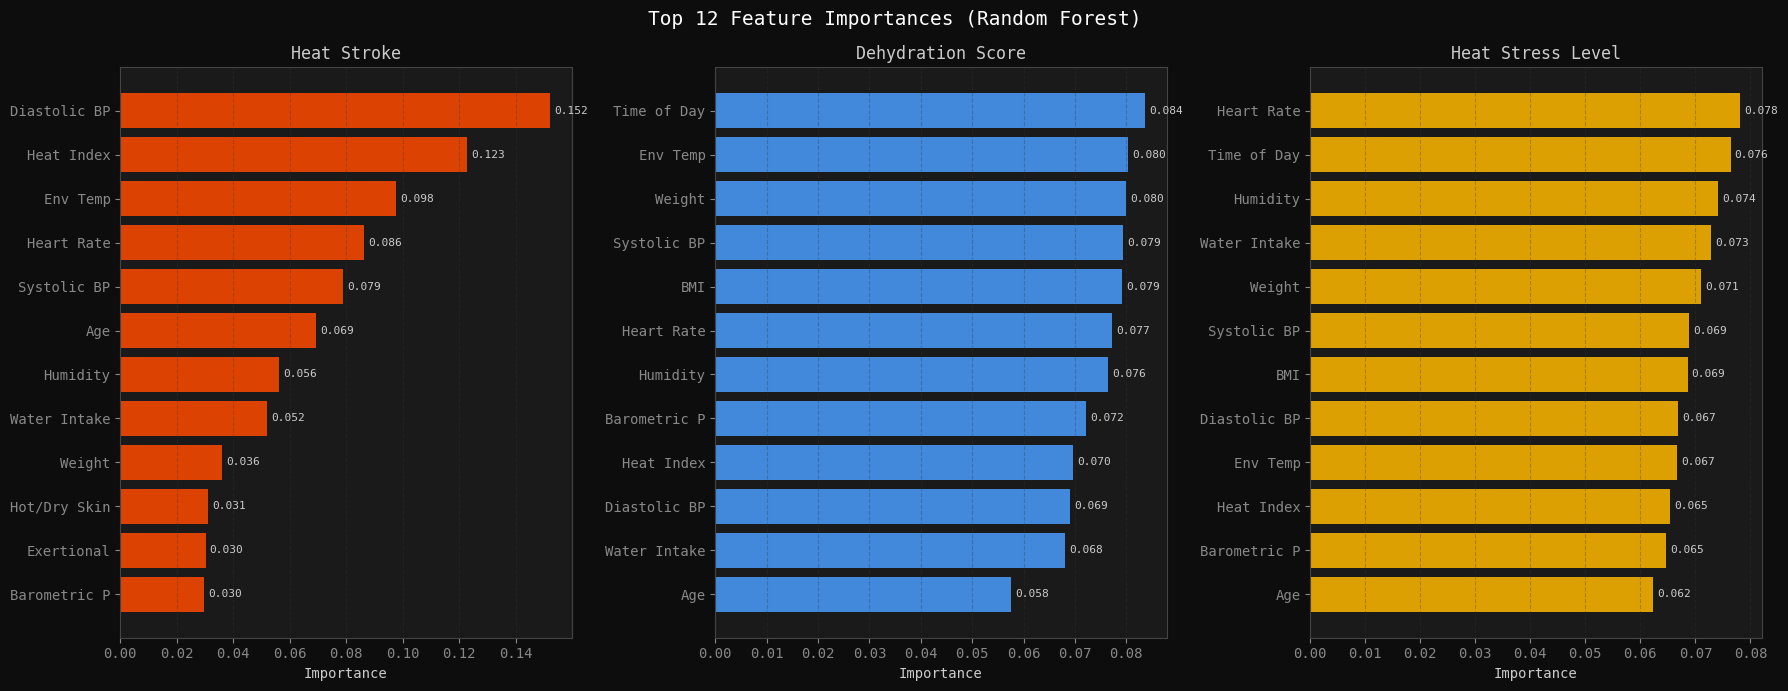

In [11]:
FEAT_LABELS = {
    'water_L':'Water Intake','month':'Month','cvd':'CVD History','HI':'Heat Index',
    'diastolic':'Diastolic BP','env_temp':'Env Temp','SCT':'Sickle Cell',
    'systolic':'Systolic BP','weight':'Weight','humidity':'Humidity',
    'sun_exposure':'Sun Exposure','BMI':'BMI','exertional':'Exertional',
    'baro':'Barometric P','HR':'Heart Rate','age':'Age','sweating':'Sweating',
    'skin_color':'Skin Color','exercise':'Exercise','sex':'Sex',
    'hot_dry_skin':'Hot/Dry Skin','hour':'Time of Day','dehydration':'Dehydration'
}
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 12 Feature Importances (Random Forest)', fontsize=14, color='white')
for ax, model, title, color in [
    (axes[0], hs_rf,  'Heat Stroke',       FLAME),
    (axes[1], dh_rf,  'Dehydration Score', BLUE),
    (axes[2], hsl_rf, 'Heat Stress Level', GOLD),
]:
    imp  = model.feature_importances_
    idxs = np.argsort(imp)[-12:]
    vals = imp[idxs]
    lbls = [FEAT_LABELS.get(FEATURES[i], FEATURES[i]) for i in idxs]
    bars = ax.barh(lbls, vals, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8, color='#CCC')
    ax.set_title(title); ax.set_xlabel('Importance'); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('importance.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

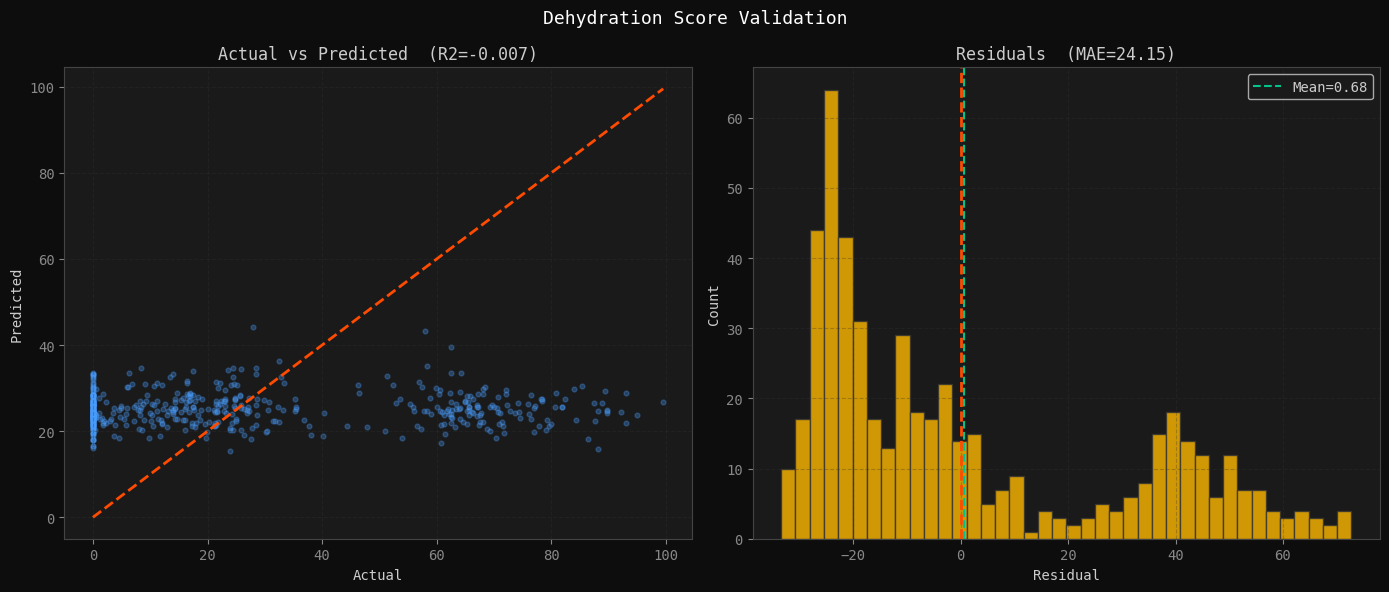

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Dehydration Score Validation', fontsize=13, color='white')

ax = axes[0]
ax.scatter(ydh_te, dh_ens, alpha=0.3, s=12, color=BLUE)
lims = [min(ydh_te.min(), dh_ens.min()), max(ydh_te.max(), dh_ens.max())]
ax.plot(lims, lims, '--', color=FLAME, lw=2)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'Actual vs Predicted  (R2={r2_score(ydh_te,dh_ens):.3f})')
ax.grid(True, alpha=0.3)

ax = axes[1]
residuals = ydh_te - dh_ens
ax.hist(residuals, bins=40, color=GOLD, alpha=0.8, edgecolor='#333')
ax.axvline(0, color=FLAME, lw=2, ls='--')
ax.axvline(residuals.mean(), color=GREEN, lw=1.5, ls='--', label=f'Mean={residuals.mean():.2f}')
ax.set_xlabel('Residual'); ax.set_ylabel('Count')
ax.set_title(f'Residuals  (MAE={mean_absolute_error(ydh_te,dh_ens):.2f})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dehydration_val.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

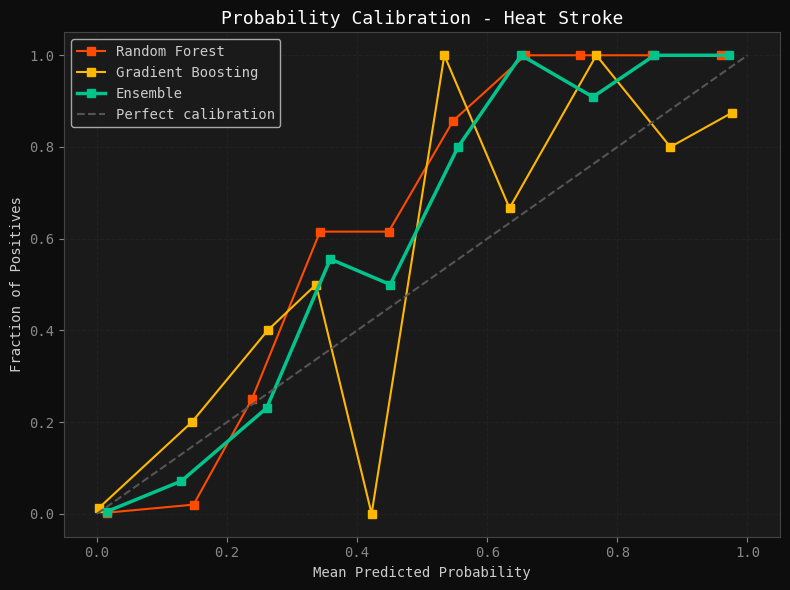

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Probability Calibration - Heat Stroke', fontsize=13, color='white')
for probs, name, color in [
    (hs_rf.predict_proba(X_te)[:,1],'Random Forest',FLAME),
    (hs_gb.predict_proba(X_te)[:,1],'Gradient Boosting',GOLD),
    (hs_ens,'Ensemble',GREEN),
]:
    frac_pos, mean_pred = calibration_curve(yhs_te, probs, n_bins=10)
    lw = 2.5 if name=='Ensemble' else 1.5
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=lw, ms=6, label=name)
ax.plot([0,1],[0,1],'--',color='#555',lw=1.5,label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

Running 5-fold cross-validation (~2 min)...
  RF: 0.9839 +/- 0.0038
  GB: 0.9766 +/- 0.0082
  LR: 0.9446 +/- 0.0143


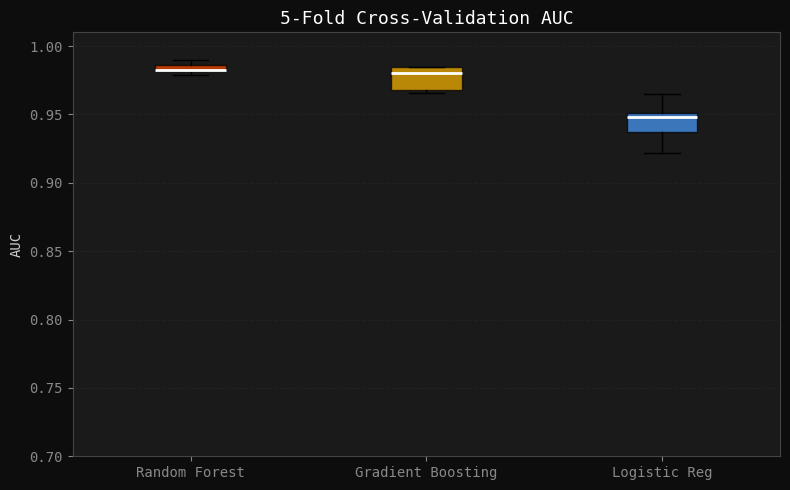

In [14]:
print('Running 5-fold cross-validation (~2 min)...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for model, name in [(hs_rf,'RF'),(hs_gb,'GB'),(hs_lr,'LR')]:
    scores = cross_val_score(model, X, y_hs, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name}: {scores.mean():.4f} +/- {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('5-Fold Cross-Validation AUC', fontsize=13, color='white')
bp = ax.boxplot([cv_results['RF'],cv_results['GB'],cv_results['LR']],
                labels=['Random Forest','Gradient Boosting','Logistic Reg'],
                patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'],[FLAME,GOLD,BLUE]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('AUC'); ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(0.7, 1.01)
plt.tight_layout()
plt.savefig('crossval.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

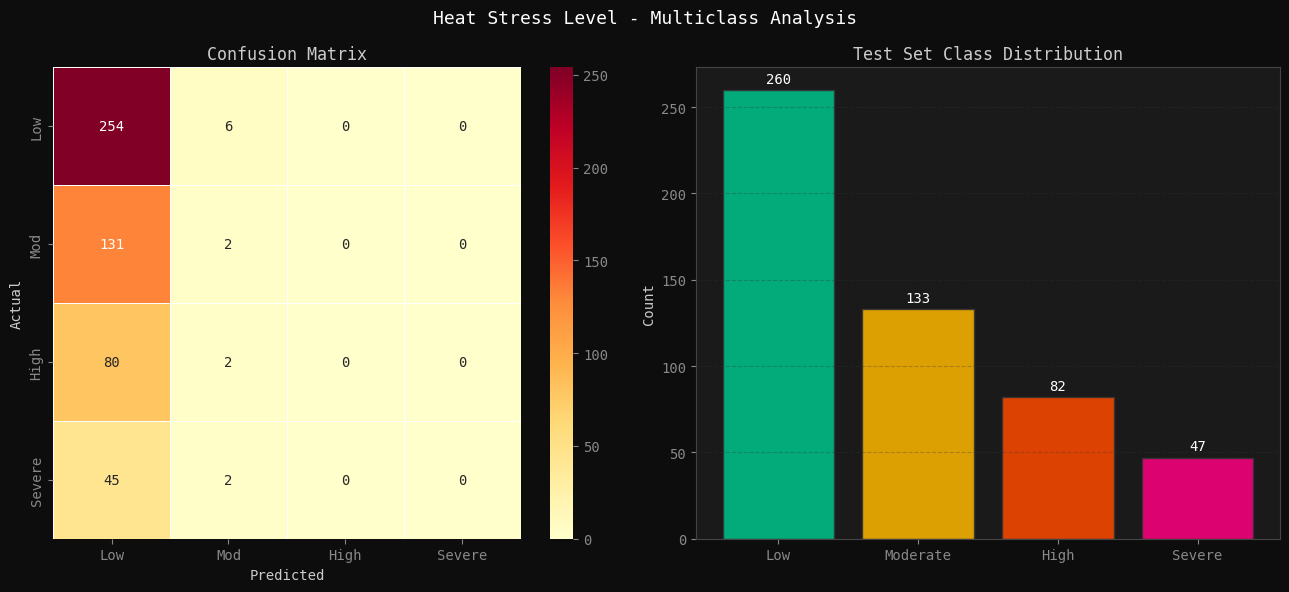

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Heat Stress Level - Multiclass Analysis', fontsize=13, color='white')
cm = confusion_matrix(yhl_te, hsl_ens)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Low','Mod','High','Severe'],
            yticklabels=['Low','Mod','High','Severe'], cbar=True, linewidths=0.5)
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
counts = pd.Series(yhl_te).value_counts().sort_index()
bars = axes[1].bar(['Low','Moderate','High','Severe'], counts.values,
                   color=[GREEN,GOLD,FLAME,'#FF0080'], alpha=0.85, edgecolor='#333')
axes[1].bar_label(bars, padding=3, color='white')
axes[1].set_title('Test Set Class Distribution'); axes[1].set_ylabel('Count'); axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('heat_stress.png', dpi=150, bbox_inches='tight', facecolor='#0D0D0D')
plt.show()

## Save & Download

In [16]:
os.makedirs('models', exist_ok=True)
bundle = {
    'features': FEATURES,
    'scaler':   scaler,
    'heat_stroke':       {'rf':hs_rf, 'gb':hs_gb, 'lr':hs_lr, 'weights':hs_w},
    'dehydration_score': {'rf':dh_rf, 'gb':dh_gb, 'lr':dh_lr, 'weights':dh_w},
    'heat_stress_level': {'rf':hsl_rf,'gb':hsl_gb,'weights':[0.55,0.45]},
    'meta': {
        'n_samples': len(df), 'n_real': len(df_real), 'n_synthetic': len(df_syn),
        'features':  FEATURES, 'prevalence': float(y_hs.mean()),
        'hs_auc':    float(roc_auc_score(yhs_te, hs_ens)),
        'dh_mae':    float(mean_absolute_error(ydh_te, dh_ens)),
        'hsl_acc':   float(accuracy_score(yhl_te, hsl_ens)),
    }
}
joblib.dump(bundle, 'models/ensemble.joblib', compress=3)
size = os.path.getsize('models/ensemble.joblib') / 1024
print(f'Saved: models/ensemble.joblib  ({size:.0f} KB)')
print(f'  Heat stroke AUC:      {bundle["meta"]["hs_auc"]:.4f}')
print(f'  Dehydration MAE:      {bundle["meta"]["dh_mae"]:.3f}')
print(f'  Heat stress accuracy: {bundle["meta"]["hsl_acc"]:.4f}')

Saved: models/ensemble.joblib  (3104 KB)
  Heat stroke AUC:      0.9873
  Dehydration MAE:      24.149
  Heat stress accuracy: 0.4904


In [18]:
from google.colab import files
import zipfile

files.download('models/ensemble.joblib')

plots = ['eda.png','correlation.png','roc_pr.png','confusion.png',
         'importance.png','dehydration_val.png','calibration.png',
         'crossval.png','heat_stress.png']

with zipfile.ZipFile('ml_plots.zip','w') as z:
    for f in plots:
        if os.path.exists(f):
            z.write(f)

files.download('ml_plots.zip')
print('Downloads started')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started
